# pMHC:TCR PAE by condition

This notebook loads the TCR-pMHC prediction statistics, classifies each row into one of three conditions, and plots the `pmhc_tcr_pae` distribution:

- **binder**: `query == 1`
- **computational negative**: peptide is `KNCFRMTDQEAIQD`
- **experimental negative**: everything else

Binder classification takes precedence over the peptide-based rule.

## 1. Import Required Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import seaborn as sns
    HAS_SEABORN = True
    sns.set_theme(style="whitegrid")
except ImportError:
    HAS_SEABORN = False
    print("seaborn not available; falling back to matplotlib only")

## 2. Load the Dataset

In [2]:
csv_path = "data/combined_df_merged_stats_pyrosetta_previous_runApr2025.csv"
df = pd.read_csv(csv_path)

print("shape:", df.shape)
df[["query", "peptide", "pmhc_tcr_pae"]].head()

shape: (102, 69)


,query,peptide,pmhc_tcr_pae
0,0,CLAVEEVSL,8.787628
1,0,KNCFRMTDQEAIQD,9.291722
2,0,CLAVEEVSL,7.530051
3,0,KNCFRMTDQEAIQD,9.967318
4,0,CLAVEEVSL,6.720963


## 3. Assign Condition Categories

Rows are labeled as `binder` where `query == 1`, `computational negative` where the peptide equals `KNCFRMTDQEAIQD`, and `experimental negative` otherwise. Binder takes precedence so a `query == 1` row is never re-labeled as a computational negative.

In [3]:
COMP_NEG_PEPTIDE = "KNCFRMTDQEAIQD"

conditions = [
    df["query"] == 1,
    df["peptide"] == COMP_NEG_PEPTIDE,
]
choices = ["binder", "computational negative"]
df["condition"] = np.select(conditions, choices, default="experimental negative")

# fixed order for plotting / summaries
condition_order = ["binder", "experimental negative", "computational negative"]
df["condition"] = pd.Categorical(df["condition"], categories=condition_order, ordered=True)

df["condition"].value_counts().reindex(condition_order)

condition
binder                     3
experimental negative     65
computational negative    34
Name: count, dtype: int64

## 4. Summarize pmhc_tcr_pae by Condition

In [4]:
summary = (
    df.groupby("condition", observed=True)["pmhc_tcr_pae"]
    .agg(count="count", mean="mean", median="median", std="std", min="min", max="max")
    .reindex(condition_order)
)
summary

,count,mean,median,std,min,max
condition,,,,,,
binder,3,5.924010,5.552423,0.822522,5.352847,6.866761
experimental negative,65,8.498131,8.405190,1.563248,5.715913,11.912151
computational negative,34,10.337675,10.165083,1.919245,7.564515,13.546622


## 5. Plot pmhc_tcr_pae by Condition

saved: /data/yzy21/yy/af/tcrdock/cancer/tcrdock_cancer_viz/pmhc_tcr_pae_by_condition.pdf


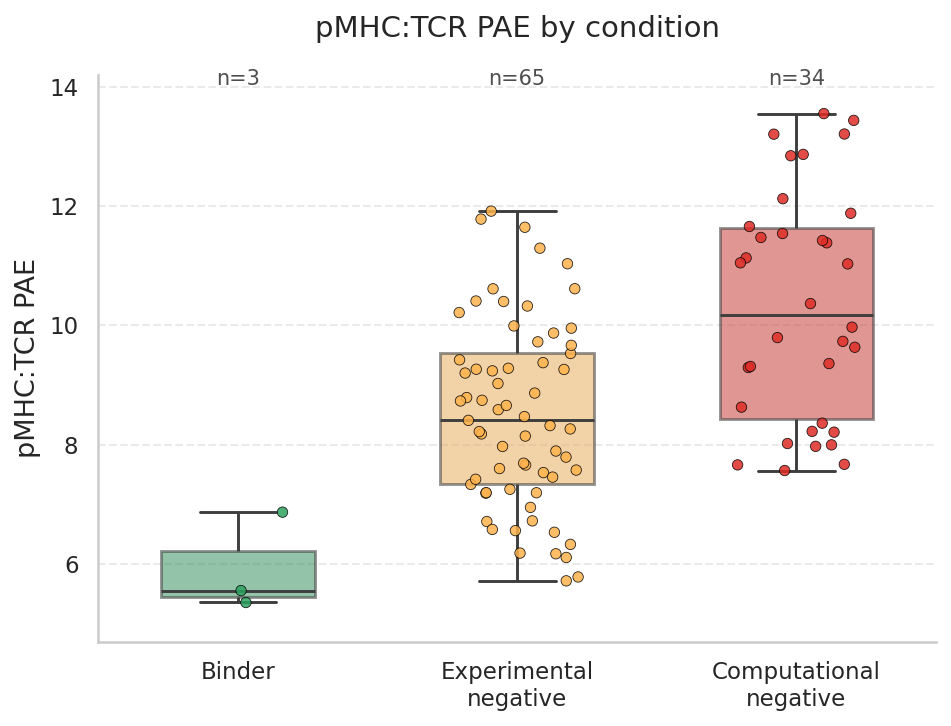

In [5]:
from pathlib import Path

# pretty styling
palette = {
    "binder": "#2ca25f",                  # green
    "experimental negative": "#feb24c",   # amber
    "computational negative": "#de2d26",  # red
}
labels = {
    "binder": "Binder",
    "experimental negative": "Experimental\nnegative",
    "computational negative": "Computational\nnegative",
}

plt.rcParams.update({
    "font.size": 12,
    "axes.titlesize": 14,
    "axes.labelsize": 13,
    "svg.fonttype": "none",
})

fig, ax = plt.subplots(figsize=(6.5, 5), dpi=150)

if HAS_SEABORN:
    sns.boxplot(
        data=df, x="condition", y="pmhc_tcr_pae", order=condition_order,
        hue="condition", palette=palette, legend=False,
        showfliers=False, width=0.55, linewidth=1.4,
        boxprops=dict(alpha=0.55), ax=ax,
    )
    sns.stripplot(
        data=df, x="condition", y="pmhc_tcr_pae", order=condition_order,
        hue="condition", palette=palette, legend=False,
        edgecolor="black", linewidth=0.4, alpha=0.85, size=5,
        jitter=0.22, ax=ax,
    )
else:
    data_by_cond = [df.loc[df["condition"] == c, "pmhc_tcr_pae"].values for c in condition_order]
    bp = ax.boxplot(data_by_cond, labels=condition_order, showfliers=False,
                    widths=0.55, patch_artist=True)
    for patch, c in zip(bp["boxes"], condition_order):
        patch.set_facecolor(palette[c]); patch.set_alpha(0.55)
    for i, (vals, c) in enumerate(zip(data_by_cond, condition_order), start=1):
        x = np.random.normal(i, 0.07, size=len(vals))
        ax.scatter(x, vals, color=palette[c], edgecolor="black",
                   linewidth=0.4, alpha=0.85, s=25)

# annotate group means
means = df.groupby("condition", observed=True)["pmhc_tcr_pae"].mean().reindex(condition_order)
for i, c in enumerate(condition_order):
    ax.text(i, ax.get_ylim()[1], f"n={int((df['condition'] == c).sum())}",
            ha="center", va="bottom", fontsize=10, color="0.3")

ax.set_xticks(range(len(condition_order)))
ax.set_xticklabels([labels[c] for c in condition_order])
ax.set_xlabel("")
ax.set_ylabel("pMHC:TCR PAE")
ax.set_title("pMHC:TCR PAE by condition", pad=18)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", linestyle="--", alpha=0.4)
ax.margins(y=0.08)
fig.tight_layout()

out_pdf = Path("pmhc_tcr_pae_by_condition.pdf")
fig.savefig(out_pdf, bbox_inches="tight")
print(f"saved: {out_pdf.resolve()}")
plt.show()